# Midterm Solution

#### name: Saiyedul Abrar
#### email: saiyedul.abrar1430@gmail.com

## Importing Functions

In [1134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


## Data Loading

In [1135]:
df = pd.read_csv('adult_income.csv') 
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [1136]:
df['occupation'] = df['occupation'].str.strip()
df['workclass'] = df['workclass'].str.strip()
df = df.replace('?', np.nan)

In [1137]:
print(df[['workclass', 'occupation']].isnull().sum())

workclass     2799
occupation    2809
dtype: int64


In [1138]:
df.sample(20)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
28903,50,Private,271262,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,>50K
42324,19,Private,378418,HS-grad,9,Never-married,Other-service,Unmarried,White,Female,0,0,30,United-States,<=50K.
14684,22,Private,374313,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,50,United-States,>50K
42620,19,Private,238144,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,20,United-States,<=50K.
3240,34,Private,56883,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
30867,32,Private,143604,10th,6,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,37,United-States,<=50K
41096,40,Private,111779,11th,7,Divorced,Other-service,Unmarried,Black,Female,0,0,36,United-States,<=50K.
25885,28,Self-emp-not-inc,227890,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Black,Male,0,0,50,United-States,>50K
3007,49,Private,44434,Some-college,10,Divorced,Tech-support,Other-relative,White,Male,0,0,35,United-States,<=50K
41232,58,Private,153551,HS-grad,9,Divorced,Sales,Unmarried,White,Female,0,0,23,United-States,<=50K.


In [1139]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [1140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [1141]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country       0
income               0
dtype: int64

## Question 1: Exploratory Data Analysis (EDA)

In [1142]:
df['income'].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

In [1143]:
df['income'] = df['income'].str.replace('.', '', regex=False)

In [1144]:
df['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [1145]:
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

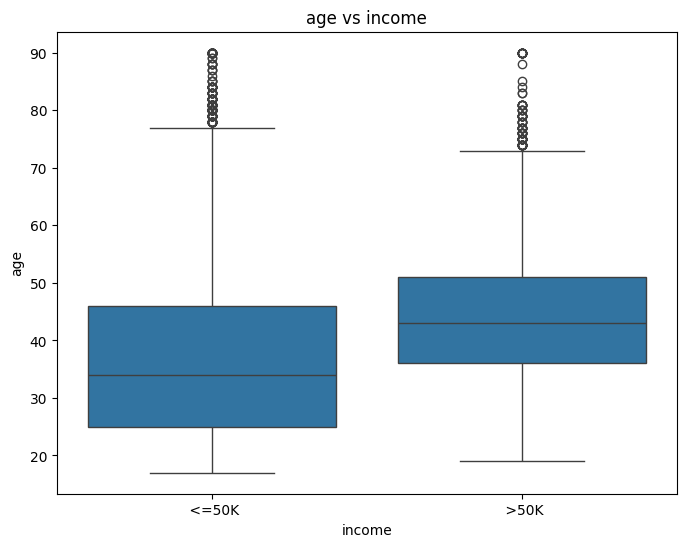

In [1146]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='age', data=df)
plt.title('age vs income')
plt.show()

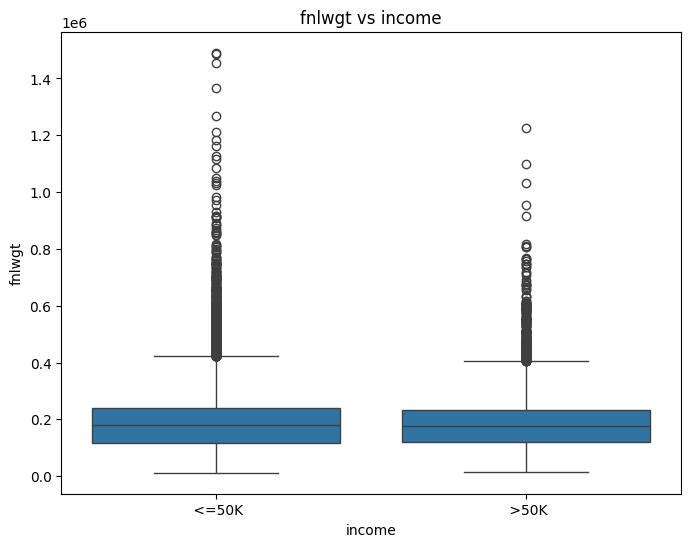

In [1147]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='fnlwgt', data=df)
plt.title('fnlwgt vs income')
plt.show()

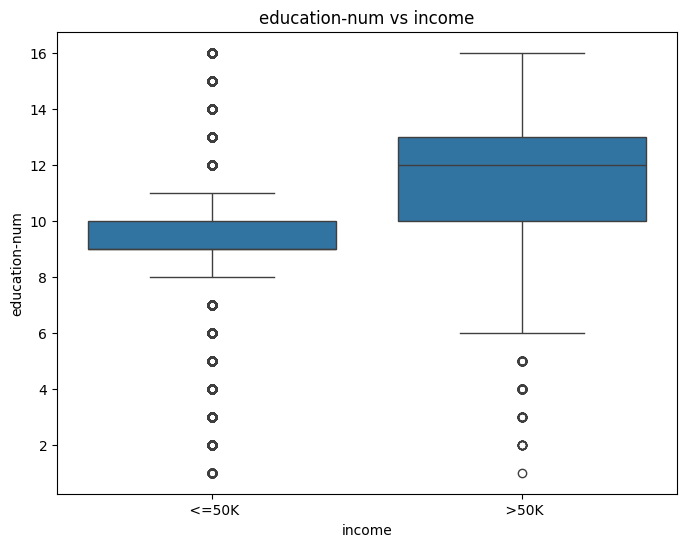

In [1148]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='education-num', data=df)
plt.title('education-num vs income')
plt.show()

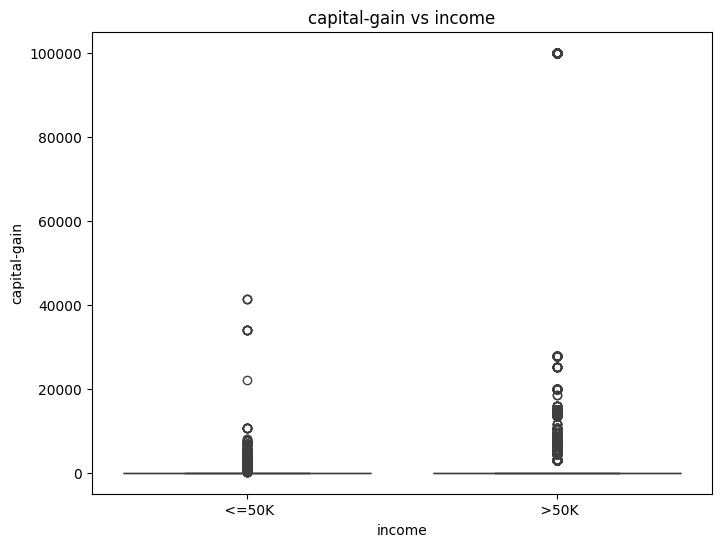

In [1149]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='capital-gain', data=df)
plt.title('capital-gain vs income')
plt.show()

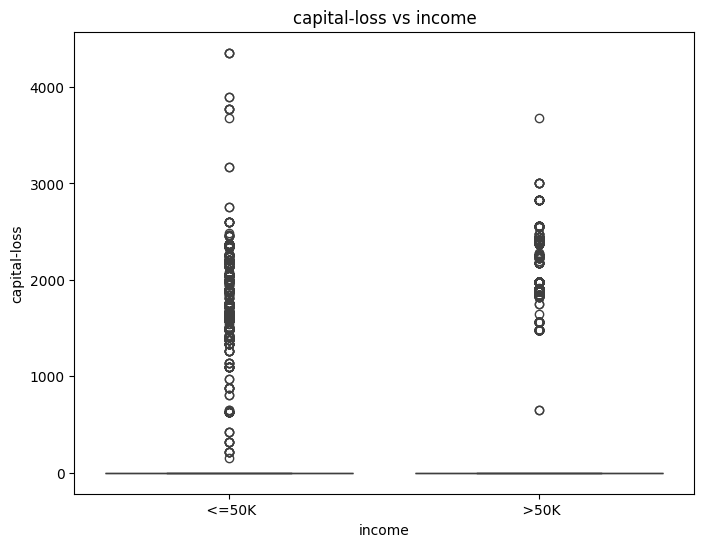

In [1150]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='capital-loss', data=df)
plt.title('capital-loss vs income')
plt.show()

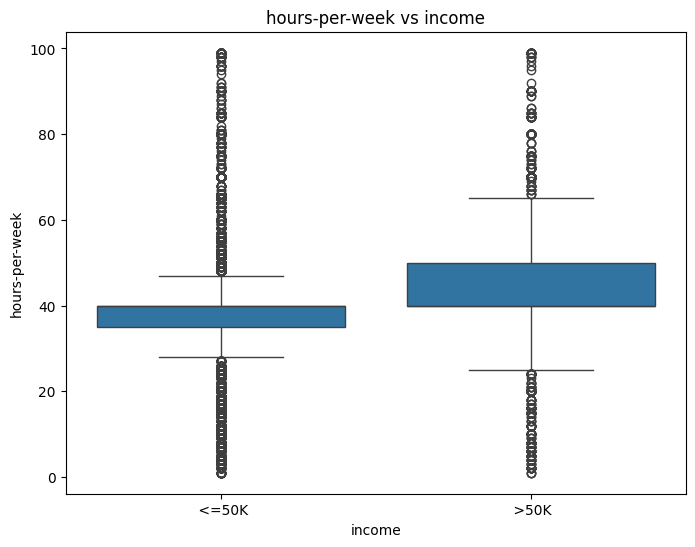

In [1151]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title('hours-per-week vs income')
plt.show()

In [1152]:
df.groupby('income')[num_cols].mean()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
income,,,,,,
<=50K,36.872184,190039.565523,9.598493,147.010308,54.151931,38.840048
>50K,44.275178,188470.574570,11.602807,4042.239497,193.528964,45.452896


In [1153]:
df.groupby('workclass')['income'].value_counts(normalize=True)

workclass         income
Federal-gov       <=50K     0.608240
                  >50K      0.391760
Local-gov         <=50K     0.704401
                  >50K      0.295599
Never-worked      <=50K     1.000000
Private           <=50K     0.782133
                  >50K      0.217867
Self-emp-inc      >50K      0.553392
                  <=50K     0.446608
Self-emp-not-inc  <=50K     0.721129
                  >50K      0.278871
State-gov         <=50K     0.732458
                  >50K      0.267542
Without-pay       <=50K     0.904762
                  >50K      0.095238
Name: proportion, dtype: float64

In [1154]:
df.groupby('education')['income'].value_counts(normalize=True)

education     income
10th          <=50K     0.937365
              >50K      0.062635
11th          <=50K     0.949227
              >50K      0.050773
12th          <=50K     0.926941
              >50K      0.073059
1st-4th       <=50K     0.967611
              >50K      0.032389
5th-6th       <=50K     0.946955
              >50K      0.053045
7th-8th       <=50K     0.935079
              >50K      0.064921
9th           <=50K     0.945767
              >50K      0.054233
Assoc-acdm    <=50K     0.742036
              >50K      0.257964
Assoc-voc     <=50K     0.746725
              >50K      0.253275
Bachelors     <=50K     0.587165
              >50K      0.412835
Doctorate     >50K      0.725589
              <=50K     0.274411
HS-grad       <=50K     0.841422
              >50K      0.158578
Masters       >50K      0.549116
              <=50K     0.450884
Preschool     <=50K     0.987952
              >50K      0.012048
Prof-school   >50K      0.739808
              <=50K   

In [1155]:
df.groupby('marital-status')['income'].value_counts(normalize=True)

marital-status         income
Divorced               <=50K     0.898839
                       >50K      0.101161
Married-AF-spouse      <=50K     0.621622
                       >50K      0.378378
Married-civ-spouse     <=50K     0.553867
                       >50K      0.446133
Married-spouse-absent  <=50K     0.907643
                       >50K      0.092357
Never-married          <=50K     0.954520
                       >50K      0.045480
Separated              <=50K     0.935294
                       >50K      0.064706
Widowed                <=50K     0.915679
                       >50K      0.084321
Name: proportion, dtype: float64

In [1156]:
df.groupby('occupation')['income'].value_counts(normalize=True)

occupation         income
Adm-clerical       <=50K     0.863126
                   >50K      0.136874
Armed-Forces       <=50K     0.666667
                   >50K      0.333333
Craft-repair       <=50K     0.773724
                   >50K      0.226276
Exec-managerial    <=50K     0.522182
                   >50K      0.477818
Farming-fishing    <=50K     0.883893
                   >50K      0.116107
Handlers-cleaners  <=50K     0.933398
                   >50K      0.066602
Machine-op-inspct  <=50K     0.876903
                   >50K      0.123097
Other-service      <=50K     0.958562
                   >50K      0.041438
Priv-house-serv    <=50K     0.987603
                   >50K      0.012397
Prof-specialty     <=50K     0.548931
                   >50K      0.451069
Protective-serv    <=50K     0.686673
                   >50K      0.313327
Sales              <=50K     0.732013
                   >50K      0.267987
Tech-support       <=50K     0.709544
                   >50K 

In [1157]:
df.groupby('relationship')['income'].value_counts(normalize=True)

relationship    income
Husband         <=50K     0.551329
                >50K      0.448671
Not-in-family   <=50K     0.898593
                >50K      0.101407
Other-relative  <=50K     0.965471
                >50K      0.034529
Own-child       <=50K     0.985358
                >50K      0.014642
Unmarried       <=50K     0.939707
                >50K      0.060293
Wife            <=50K     0.531103
                >50K      0.468897
Name: proportion, dtype: float64

In [1158]:
df.groupby('race')['income'].value_counts(normalize=True)

race                income
Amer-Indian-Eskimo  <=50K     0.882979
                    >50K      0.117021
Asian-Pac-Islander  <=50K     0.730744
                    >50K      0.269256
Black               <=50K     0.879189
                    >50K      0.120811
Other               <=50K     0.876847
                    >50K      0.123153
White               <=50K     0.746013
                    >50K      0.253987
Name: proportion, dtype: float64

In [1159]:
df.groupby('sex')['income'].value_counts(normalize=True)

sex     income
Female  <=50K     0.890749
        >50K      0.109251
Male    <=50K     0.696233
        >50K      0.303767
Name: proportion, dtype: float64

In [1160]:
df.groupby('native-country')['income'].value_counts(normalize=True)

native-country  income
?               <=50K     0.743291
                >50K      0.256709
Cambodia        <=50K     0.678571
                >50K      0.321429
Canada          <=50K     0.653846
                            ...   
United-States   >50K      0.243977
Vietnam         <=50K     0.918605
                >50K      0.081395
Yugoslavia      <=50K     0.652174
                >50K      0.347826
Name: proportion, Length: 83, dtype: float64

<Figure size 1000x600 with 0 Axes>

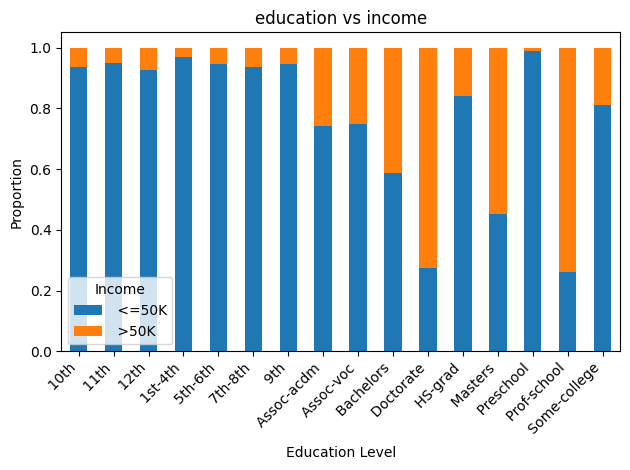

In [1161]:
plt.figure(figsize=(10, 6))
pd.crosstab(df['education'], df['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('education vs income')
plt.ylabel('Proportion')
plt.xlabel('Education Level')
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

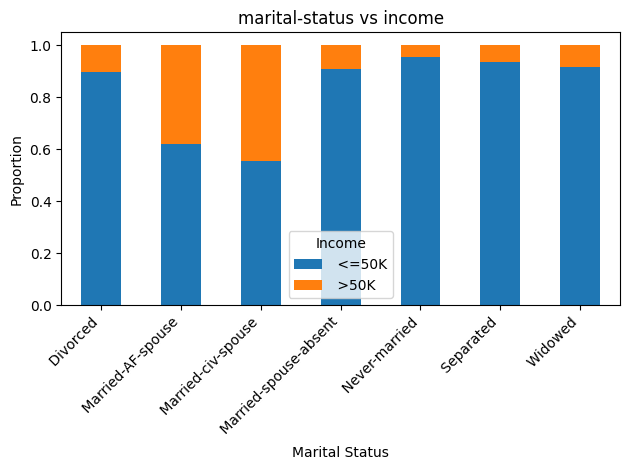

In [1162]:
plt.figure(figsize=(10, 6))
pd.crosstab(df['marital-status'], df['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('marital-status vs income')
plt.ylabel('Proportion')
plt.xlabel('Marital Status')
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

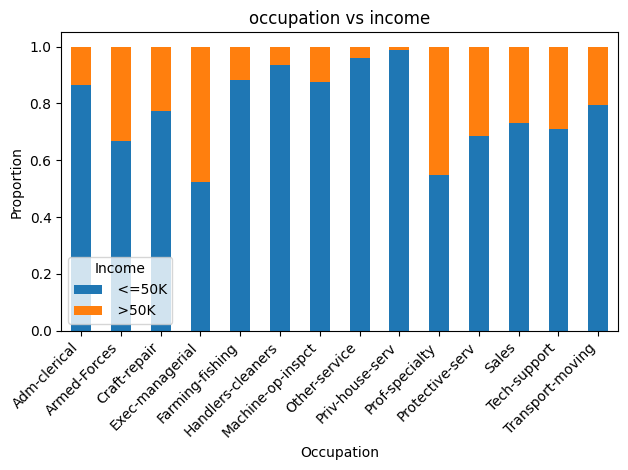

In [1163]:
plt.figure(figsize=(10, 6))
pd.crosstab(df['occupation'], df['income'], normalize='index').plot(kind='bar', stacked=True)
plt.title('occupation vs income')
plt.ylabel('Proportion')
plt.xlabel('Occupation')
plt.legend(title='Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Selection of Top 3 Features:
## 
1. education-num: This is a numerical representation of education level. The boxplot shows a clear upward shift for the >50K group; the mean education-num for >50K is around 12 (some college) vs about 9.5 for <=50K. Higher education typically leads to better job opportunities and higher income, making it a strong predictor.
## 
2. capital-gain: This feature has a highly skewed distribution; most people have 0 capital gain, but those with any gain tend to have much higher income. The mean capital gain for >50K is over 5,000 vs ~200 for <=50K. This indicates that investment income is a strong separator, though it applies to a minority.
## 
3. hours-per-week: People earning >50K tend to work more hours (mean ~45 vs 40). Working longer hours often correlates with higher pay or salaried positions, so it intuitively affects income.
## 
# Ranking:
1. 1st education-num – most important because it is a fundamental determinant of earning potential across the population; the difference is consistent and large.
2. 2nd capital-gain – very strong but affects fewer individuals; still a decisive factor when present.
3. 3rd hours-per-week – important but less discriminative than the first two; many low-income individuals also work full-time, so the separation is weaker.


## Question 2: Preprocessing Pipeline Design (Regression)

In [1164]:
X = df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

In [1165]:
num_features = ['age','fnlwgt','education-num','capital-gain','capital-loss']
cat_features = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


In [1166]:
preprocessor = ColumnTransformer([
    ('numerical', num_pipeline, num_features),
    ('categorical', cat_pipeline, cat_features)
])

In [1167]:
preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Numerical Columns ar (age, fnlwgt, education-num, capital-gain, capital-loss) Preprocessing Applied "Median Imputation" cause Robust against outliers and handles missing values and also used StandardScaler to scales features to the same range for better regression performance.

Categorical columns are (workclass, education, marital-status, occupation, relationship, race, sex, native-country, income) Preprocessing Applied Most Frequent Imputation cause it  replaces missing categorical values using the most common category, and also used OneHotEncoder that Converts categorical values into numerical format required by machine learning models



## Question 3: Regression Modeling & Evaluation

In [1168]:
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

In [1169]:
linear_pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1170]:
linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)

print("Linear Regression Performance")
print(f"R2 : {linear_r2*100:.4f}")
print(f"MAE : {linear_mae*100:.4f}")
print(f"MSE : {linear_mse*100:.4f}")

Linear Regression Performance
R2 : 19.5695
MAE : 767.4405
MSE : 12331.4481


In [1171]:
sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SGDRegressor(
        random_state=42,
    ))
])

sgd_pipeline.fit(X_train, y_train)

sgd_pred = sgd_pipeline.predict(X_test)

In [1172]:
sgd_pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1173]:
sgd_r2 = r2_score(y_test, sgd_pred)
sgd_mae = mean_absolute_error(y_test, sgd_pred)
sgd_mse = mean_squared_error(y_test, sgd_pred)

print("SGD Regressor Performance")
print(f"R2 : {sgd_r2*100:.4f}")
print(f"MAE : {sgd_mae*100:.4f}")
print(f"MSE : {sgd_mse*100:.4f}")

SGD Regressor Performance
R2 : 19.6607
MAE : 765.7294
MSE : 12317.4600


In [1174]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD Regressor'],
    'R2 Score': [linear_r2, sgd_r2],
    'MAE': [linear_mae, sgd_mae],
    'MSE': [linear_mse, sgd_mse]
})

comparison

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.195695,7.674405,123.314481
1,SGD Regressor,0.196607,7.657294,123.174600


The performance of both regression models is evaluated using R2 Score, Mean Absolute Error (MAE), and Mean Squared Error (MSE). 
The better model is the one with: High R2 Score, Lower MAE, Lower MSE.
SGD Regressor performed better because it achieved a higher R2 Score and lower prediction errors. Its iterative optimization method was able to learn a better relationship between the input features and the target variable after preprocessing.

## Question 4: Classification Pipeline & Error Analysis

In [1175]:
X = df.drop('income', axis=1)
y = df['income']

In [1176]:
num_features = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

cat_features = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']

In [1177]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [1178]:
num_pipeline

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [1179]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [1180]:
cat_pipeline

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [1181]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [1182]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [1183]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [1184]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [1185]:
logistic_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1186]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1187]:
y_pred = logistic_pipeline.predict(X_test)

In [1188]:
y_pred

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      shape=(9769,), dtype=object)

In [1189]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=' >50K')
recall = recall_score(y_test, y_pred, pos_label=' >50K')

print("Logistic Regression Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall: {recall:.4f}")

Logistic Regression Performance
Accuracy : 0.8503
Precision : 0.7298
Recall: 0.5950


Accuracy is the proportion of correctly classified samples. A higher accuracy indicates better overall classification performance.

## Question 5: 

In [1190]:
knn_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier())
    ]
)

knn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1192]:
grid = {
    "knn__n_neighbors": [3, 5, 7, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [1193]:
grid_search.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.81979885        nan 0.8282702
        nan 0.83331205        nan 0.83592251]
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [1198]:
print("Best Parameters:")
print(grid_search.best_params_)
print("")
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}

Best Cross Validation Accuracy:
0.8359225097108975


In [1195]:
best_knn = grid_search.best_estimator_

In [1196]:
knn_pred = best_knn.predict(X_test)

In [1197]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, pos_label=' >50K')
knn_recall = recall_score(y_test, knn_pred, pos_label=' >50K')

print("Tuned KNN Performance")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall : {knn_recall:.4f}")

Tuned KNN Performance
Accuracy : 0.8375
Precision: 0.6847
Recall : 0.5954
